# Problem Set 2
## Sagar Clemensen (fck916)
### 25/2-2026

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from iminuit import Minuit
from iminuit import cost
from scipy import stats
from scipy.integrate import quad

r = np.random

## Problem 1a

In [2]:
df = pd.read_csv('Liverpool10k2026.csv')
df["Time"] = (df["Time"].str.replace("O", "0", regex=False))

df["seconds"] = pd.to_timedelta(df["Time"]).dt.total_seconds()
times = df["seconds"].values
df

,First Name,Last Name,Gender,Club,Time,seconds
0,Joshua,Garcia,Male,NaN,00:42:24.00,2544.0
1,William,Young,Male,NaN,00:51:18.00,3078.0
2,Renee,Daniel,Female,NaN,00:41:29.00,2489.0
3,Timothy,Barnes,Male,NaN,00:52:25.00,3145.0
4,Juan,Hensley,Male,North Endurance,00:42:51.00,2571.0
...,...,...,...,...,...,...
193,Larry,Owens,Male,NaN,00:41:06.00,2466.0
194,Pamela,Oliver,Female,NaN,01:10:05.00,4205.0
195,Jacob,Martin,Male,Dockside Runners,00:46:38.00,2798.0
196,Kerry,Smith,Female,NaN,01:04:21.00,3861.0


In [4]:
# Safe GEV function that returns 0 for invalid inputs
def GEV(x, mu, sigma, xi):
    x = np.asarray(x)
    t = 1 + xi * (x - mu) / sigma
    pdf = np.zeros_like(x, dtype=float)
    valid = t > 0
    pdf[valid] = ((1 / sigma)* t[valid]**(-1/xi - 1)* np.exp(-t[valid]**(-1/xi)))
    return pdf
def negLLHfunc(mu, sigma, xi):
    pdfVals = GEV(times, mu, sigma, xi)
    return -np.sum(np.log(pdfVals))

https://scikit-hep.org/iminuit/notebooks/cost_functions.html#Maximum-likelihood-fits

In [5]:
mfitllh = Minuit(negLLHfunc, mu=3000, sigma=600, xi=0.1)
mfitllh.errordef = Minuit.LIKELIHOOD  # important for likelihood fits!
mfitllh.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1560                       │              Nfcn = 74               │
│ EDM = 1.3e-05 (Goal: 0.0001)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ mu    │  2.96e3   │  0.05e3   │            │            │         │         │       │
│ 1 │ sigma │    610    │    40     │            │            │         │         │       │
│ 2 │ xi    │   -0.22   │   0.06    │            │            │         │         │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬────────────────────────────┐
│       │       mu    sigma       xi │
├───────┼────────────────────────────┤
│    mu │ 2.47e+03    0.3e3   -1.294 │
│ sigma │    0.3e3 1.33e+03   -1.277 │
│    xi │   -1.294   -1.277  0.00356 │
└───────┴────────────────────────────┘

In [6]:
muFit = mfitllh.values['mu']
sigmaFit = mfitllh.values['sigma']
xiFit = mfitllh.values['xi']

### Bootstrapping uncertainty estimation

#### Transformation method

In [7]:
def sample_gev(N, mu, sigma, xi):
    U = np.random.uniform(size=N)
    
    if abs(xi) > 1e-8:
        return mu + (sigma/xi) * ((-np.log(U))**(-xi) - 1)
    else:
        return mu - sigma * np.log(-np.log(U))

def paramBootTrans(Nexp, Ndata):

    muVals = np.zeros(Nexp)
    sigmaVals = np.zeros(Nexp)
    xiVals = np.zeros(Nexp)

    for i in range(Nexp):

        dataMC = sample_gev(Ndata, muFit, sigmaFit, xiFit)

        cfit = cost.UnbinnedNLL(dataMC, GEV)

        mfit = Minuit(cfit, mu=muFit, sigma=sigmaFit, xi=xiFit)
        mfit.limits["sigma"] = (1e-6, None)
        mfit.limits["xi"] = (-1, 1)

        mfit.migrad()

        muVals[i] = mfit.values["mu"]
        sigmaVals[i] = mfit.values["sigma"]
        xiVals[i] = mfit.values["xi"]

    return muVals, sigmaVals, xiVals

In [8]:
r.seed(42)
musT, sigmasT, xisT = paramBootTrans(1000, len(times))

In [9]:
# # Checking for correlations between parameters
# fig, ax = plt.subplots(1, 3, figsize=(12, 5))
# ax = ax.flatten()
# ax[0].plot(musT, sigmasT, 'o', alpha=0.5)
# ax[0].set_xlabel('mu')
# ax[0].set_ylabel('sigma')
# ax[1].plot(musT, xisT, 'o', alpha=0.5)
# ax[1].set_xlabel('mu')
# ax[1].set_ylabel('xi')
# ax[2].plot(sigmasT, xisT, 'o', alpha=0.5)
# ax[2].set_xlabel('sigma')
# ax[2].set_ylabel('xi')
# plt.tight_layout()

In [10]:
# 68.27% central interval percentiles
lower_p = 15.865
upper_p = 84.135

# Alpha interval
muLow, muHigh = np.percentile(musT, [lower_p, upper_p])

# Beta interval
sigmaLow, sigmaHigh = np.percentile(sigmasT, [lower_p, upper_p])
xiLow, xiHigh = np.percentile(xisT, [lower_p, upper_p])

print(f"68.27% interval for mu: [{muLow:.2f}, {muHigh:.2f}]")
print(f"68.27% interval for sigma:  [{sigmaLow:.2f}, {sigmaHigh:.2f}]")
print(f"68.27% interval for xi:  [{xiLow:.2f}, {xiHigh:.2f}]")
print(f"Best fit value for mu = {muFit:.2f} + {muHigh - muFit:.2f} - {muFit - muLow:.2f}")
print(f"Best fit value for sigma = {sigmaFit:.2f} + {sigmaHigh - sigmaFit:.2f} - {sigmaFit - sigmaLow:.2f}")
print(f"Best fit value for xi = {xiFit:.2f} + {xiHigh - xiFit:.2f} - {xiFit - xiLow:.2f}")

68.27% interval for mu: [2917.00, 3011.94]
68.27% interval for sigma:  [578.10, 643.17]
68.27% interval for xi:  [-0.27, -0.18]
Best fit value for mu = 2960.30 + 51.64 - 43.30
Best fit value for sigma = 613.68 + 29.49 - 35.58
Best fit value for xi = -0.22 + 0.04 - 0.05


In [11]:
for param in mfitllh.parameters:
    print(f"{param} = {mfitllh.values[param]:.2f} ± {mfitllh.errors[param]:.2f}")

mu = 2960.30 ± 49.70
sigma = 613.68 ± 36.44
xi = -0.22 ± 0.06


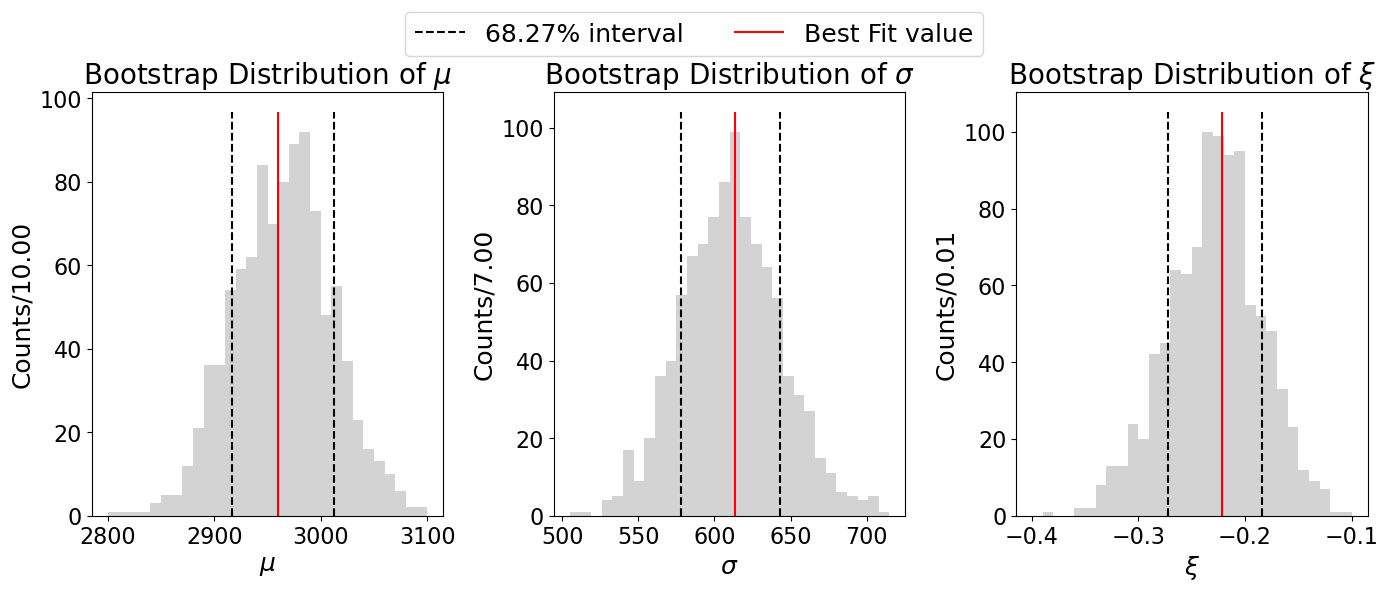

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(14, 6))
ax = ax.flatten()
Nbins = 30

xminA, xmaxA = 2800, 3100
binwidth = (xmaxA - xminA) / Nbins
ax[0].hist(musT, bins=Nbins, range=(xminA, xmaxA), color='lightgray')
yminA, ymaxA = ax[0].get_ylim()
l1 = ax[0].vlines([muLow, muHigh], yminA, ymaxA, linestyles='dashed', color='black',label='68.27% interval')
l2 = ax[0].vlines(muFit, yminA, ymaxA, color='red', label='Best Fit value')
ax[0].set_xlabel("$\\mu$", fontsize=18)
ax[0].set_ylabel(f"Counts/{binwidth:.2f}", fontsize=18)
ax[0].set_title("Bootstrap Distribution of $\\mu$", fontsize=20)
ax[0].tick_params(axis='both', which='major', labelsize=16)

xminB, xmaxB = 505, 715
binwidth = (xmaxB - xminB) / Nbins
ax[1].hist(sigmasT, bins=Nbins, range=(xminB, xmaxB), color='lightgray')
yminB, ymaxB = ax[1].get_ylim()
ax[1].vlines([sigmaLow, sigmaHigh], yminB, ymaxB, linestyles='dashed', color='black', label='68.27% interval')
ax[1].vlines(sigmaFit, yminB, ymaxB, color='red', label='Best Fit value')
ax[1].set_xlabel("$\\sigma$", fontsize=18)
ax[1].set_ylabel(f"Counts/{binwidth:.2f}", fontsize=18)
ax[1].set_title("Bootstrap Distribution of $\\sigma$", fontsize=20)
ax[1].tick_params(axis='both', which='major', labelsize=16)

xminC, xmaxC = -0.4, -0.1
binwidth = (xmaxC - xminC) / Nbins
ax[2].hist(xisT, bins=Nbins, range=(xminC, xmaxC), color='lightgray')
yminC, ymaxC = ax[2].get_ylim()
ax[2].vlines([xiLow, xiHigh], yminC, ymaxC, linestyles='dashed', color='black', label='68.27% interval')
ax[2].vlines(xiFit, yminC, ymaxC, color='red', label='Best Fit value')
ax[2].set_xlabel("$\\xi$", fontsize=18)
ax[2].set_ylabel(f"Counts/{binwidth:.2f}", fontsize=18)
ax[2].set_title("Bootstrap Distribution of $\\xi$", fontsize=20)
ax[2].tick_params(axis='both', which='major', labelsize=16)

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', fontsize=18, ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.92])  # Leave space for legend
plt.show()

In [13]:
munew = np.mean(musT)
sigmanew = np.mean(sigmasT)
xinew = np.mean(xisT)
print(f"Bootstrap means for mu, sigma, xi: {munew:.2f}, {sigmanew:.2f}, {xinew:.2f}")
print(f'Best fit value for mu, sigma, xi: {muFit:.2f}, {sigmaFit:.2f}, {xiFit:.2f}')
print(negLLHfunc(munew, sigmanew, xinew), mfitllh.fval)

Bootstrap means for mu, sigma, xi: 2964.72, 610.87, -0.23
Best fit value for mu, sigma, xi: 2960.30, 613.68, -0.22
1560.062869186179 1560.0405839337218


### Plot

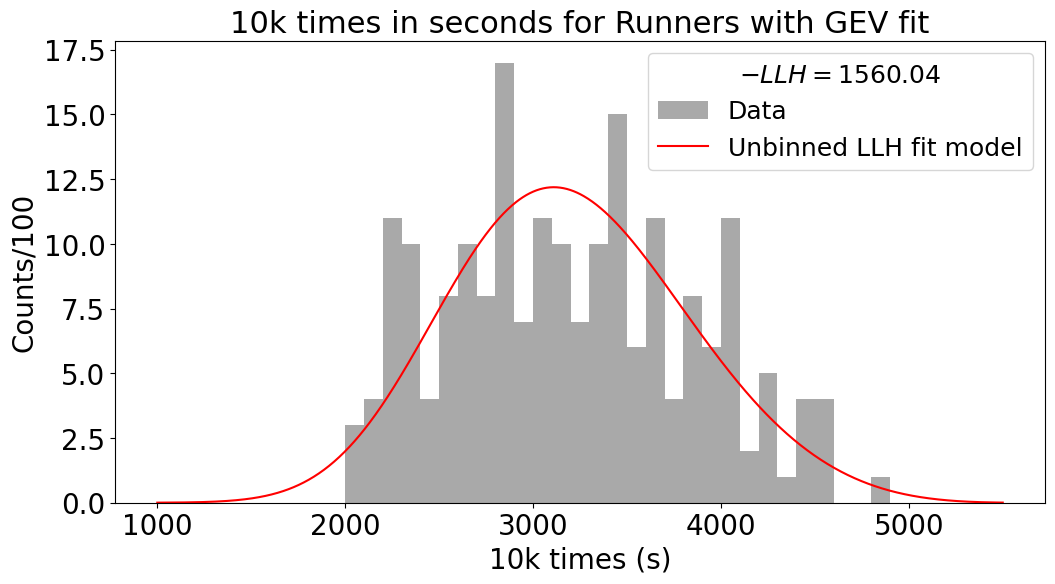

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))
# print(np.min(times), np.max(times))
Nbins = 30
xmin = 2000
xmax = 5000
binwidth = (xmax - xmin) / Nbins    
ax.hist(times, bins=Nbins, range=(xmin, xmax), label='Data', color='darkgray')
llh = mfitllh.fval

ax.set_xlabel('10k times (s)', fontsize=20)
ax.set_ylabel(f'Counts/{binwidth:.0f}', fontsize=20)
ax.set_title('10k times in seconds for Runners with GEV fit', fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=20)
xx = np.linspace(xmin-1000, xmax+500, 1000)
ax.plot(xx, GEV(xx, *mfitllh.values[:])*len(times)*binwidth, '-r', label='Unbinned LLH fit model')

plt.legend(title=f"$-LLH = {llh:.2f}$", fontsize=18, title_fontsize = 18, alignment = 'center');

## Problem 1b

In [15]:
cutoffTime = df['seconds'][df['First Name'] == 'Tanyusha'].values[0]
# print(f"Cutoff time: {cutoffTime:.2f} seconds")
# print(times[times > cutoffTime])
NSlowData = len(times[times > cutoffTime])
fracSlowData = NSlowData / len(times)

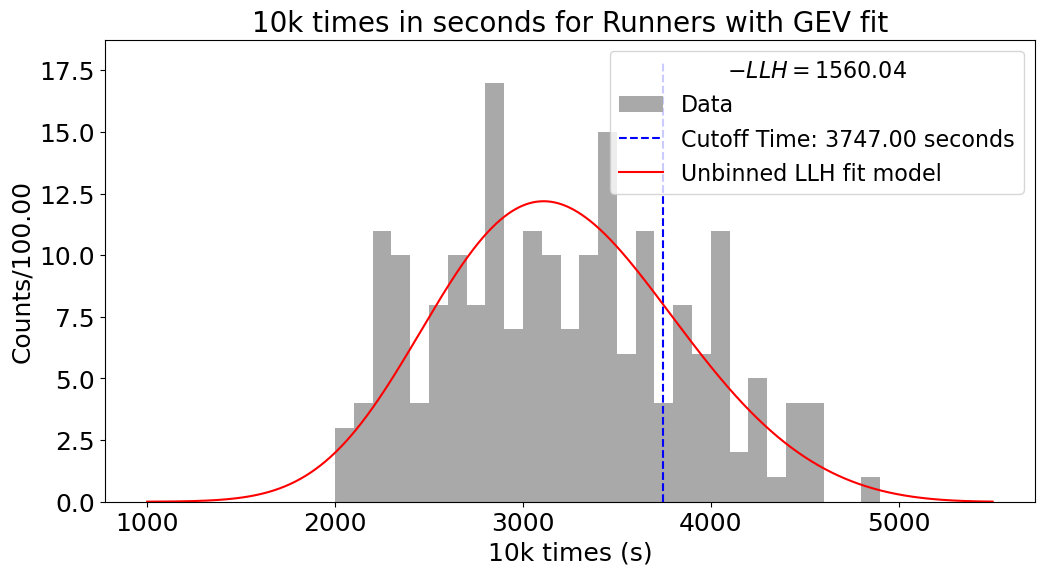

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))  
ax.hist(times, bins=Nbins, range=(xmin, xmax), label='Data', color='darkgray')

ax.set_xlabel('10k times (s)', fontsize=18)
ax.set_ylabel(f'Counts/{binwidth:.2f}', fontsize=18)
ax.set_title('10k times in seconds for Runners with GEV fit', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.vlines(x=cutoffTime, ymin=0, ymax=ax.get_ylim()[1], colors='blue', linestyles='dashed', label=f'Cutoff Time: {cutoffTime:.2f} seconds')
ax.plot(xx, GEV(xx, *mfitllh.values[:])*binwidth*len(times), '-r', label='Unbinned LLH fit model')
fit_info = [f"$-LLH = {-llh:.2f}$",]

plt.legend(title=f"$-LLH = {llh:.2f}$", fontsize=16, title_fontsize = 16, alignment = 'center');

In [17]:
def GEVcdf(x, mu, sigma, xi):
    cdf = np.exp(-1*(1 + xi * ((x - mu) / sigma))**(-1/xi))
    return cdf
xmin = cutoffTime
xmax = muFit-sigmaFit/xiFit
fracSlowFit = quad(GEV, xmin, xmax, args=(muFit, sigmaFit, xiFit))[0]
fracSlowFitUnc = quad(GEV, xmin, xmax, args=(muFit, sigmaFit, xiFit))[1]

In [18]:
analytic = 1 - GEVcdf(cutoffTime, muFit, sigmaFit, xiFit)
print(analytic, fracSlowFit, fracSlowFitUnc)

0.19849883241235833 0.19849883241264427 5.066168346406158e-11


In [ ]:
print(f"Fraction of runners slower than {cutoffTime:.2f} seconds: {fracSlowData:.f}")
print(f"Analytic result: {analytic:.4f}, Numerical result: {fracSlowFit:.4f} ± {fracSlowFitUnc:.4f}")
relError = (analytic-fracSlowData) / fracSlowData
print(f"Relative error between numerical and analytic results: {relError:.3%}")

Fraction of runners slower than 3747.00 seconds: 0.227
Analytic result: 0.1985, Numerical result: 0.1985 ± 0.0000
Relative error between numerical and analytic results: -12.775%


In [23]:
analytic2 = 1 - GEVcdf(cutoffTime, muHigh, sigmaFit, xiHigh)
print(f'Using muHigh and xiHigh the analytic result is {analytic2:.3f}')

Using muHigh and xiHigh the analytic result is 0.228


## Problem 1c

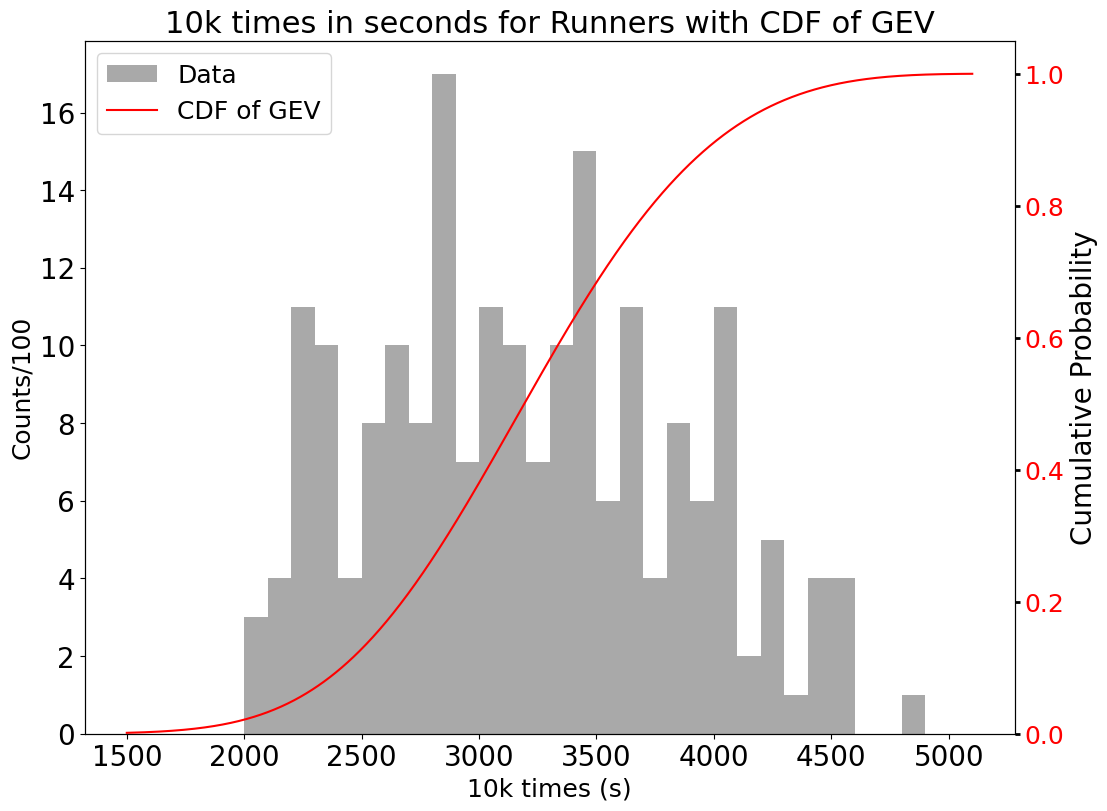

In [64]:
muC = 2980
sigmaC = 607.5
xiC = -0.26

fig, ax1 = plt.subplots(figsize=(12, 9))
Nbins=30
xmin = 2000
xmax = 5000
binwidth = (xmax - xmin) / Nbins
ax1.set_xlabel('10k times (s)', fontsize=18)
ax1.set_ylabel(f'Counts/{binwidth:.0f}', fontsize=18)

n, bins, patches = ax1.hist(times, bins=Nbins, range=(xmin, xmax), label='Data', color='darkgray')

## Separate y-axis for the CDF going from 0 to 1
ax2 = ax1.twinx()
xx = np.linspace(xmin-500, xmax+100, 1000)
line2, = ax2.plot(xx, GEVcdf(xx, muC, sigmaC, xiC), '-r', label='CDF of GEV')
# ax.set_xlabel('10k times (s)', fontsize=18)
ax2.set_ylabel('Cumulative Probability', fontsize=20)
ax1.set_title('10k times in seconds for Runners with CDF of GEV', fontsize=22)
ax1.tick_params(axis='both', which='major', labelsize=20)
ax2.tick_params(axis='y', width=2, labelcolor='red', labelsize=18)
lines = [patches[0], line2]
labels = ['Data', 'CDF of GEV']
ax1.legend(lines, labels, loc='upper left', fontsize=18)
ax1.set_ylim(bottom=0)
ax2.set_ylim(0, 1.05);

In [65]:
fastest = np.min(times)
print(f"Fastest time: {fastest:.2f} seconds")
PFaster = GEVcdf(fastest, muC, sigmaC, xiC)
print(f"Probability of a runner being faster than {fastest:.2f} seconds: {PFaster:.4f}")

Fastest time: 2005.00 seconds
Probability of a runner being faster than 2005.00 seconds: 0.0218


## Problem 2

### By solving the equation $\frac{1}{N}\cdot1.6 + \frac{2.66}{N}\cdot0.5 = 1$ for N, we get $N = 2.93$.

In [66]:
def prior(x):
    N = 2.93
    result = np.zeros_like(x)
    result[(x > 0) & (x <= 1.6)] = 1 / N
    result[(x > 1.6) & (x <= 2.1)] = 2.66 / N
    result[(x <= 0) | (x > 2.1)] = 0
    return result
def likelihood(x):
    alpha = 2
    beta = 2
    return stats.gamma.pdf(x, a=alpha, scale=1/beta)
def posterior(x):
    return likelihood(x) * prior(x)

In [67]:
xvals = np.linspace(0, 4, 1000, endpoint=False)[1:]
NLh = quad(likelihood, xvals[0], xvals[-1])[0]
NPost = quad(posterior, xvals[0], xvals[-1])[0]
print(f"Normalization Constants: Likelihood = {NLh:.4f}, Posterior = {NPost:.4f}")

Normalization Constants: Likelihood = 0.9969, Posterior = 0.3675


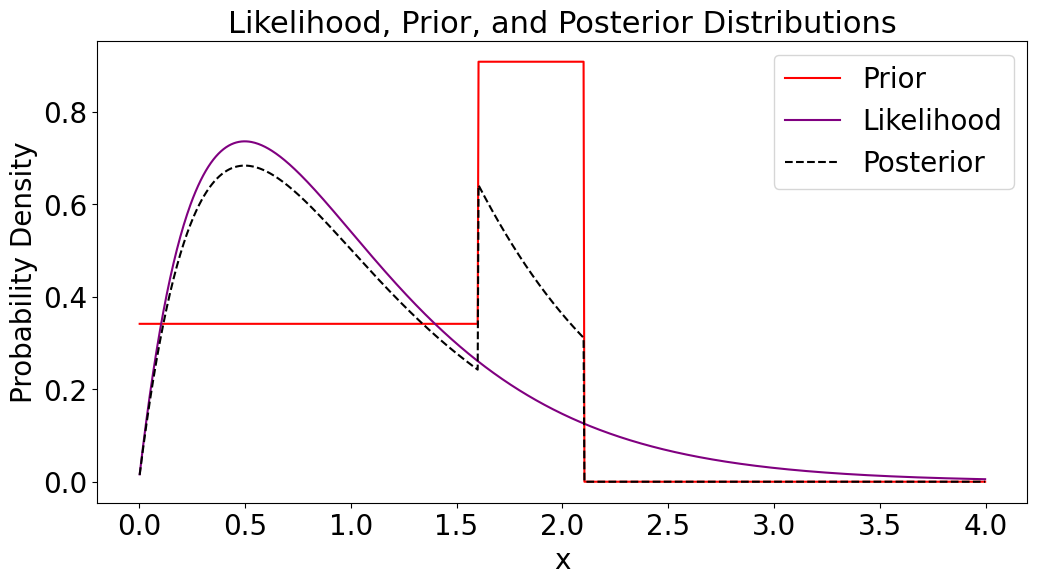

In [68]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(xvals, prior(xvals), label='Prior', color='red')
ax.plot(xvals, likelihood(xvals), label='Likelihood', color='purple')
ax.plot(xvals, likelihood(xvals) * prior(xvals)/NPost, '--', label='Posterior', color='black')
ax.legend(fontsize=20)
ax.set_xlabel('x', fontsize=20)
ax.set_ylabel('Probability Density', fontsize=20)
ax.set_title('Likelihood, Prior, and Posterior Distributions', fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=20)

In [69]:
xEst = xvals[np.argmax(posterior(xvals)/NPost)]
print(np.max(posterior(xvals[:250])/NPost), np.max(posterior(xvals[250:])/NPost))
print(f"Estimated x that maximizes the posterior: {xEst:.4f}")
print(f"Posterior at xEst: {posterior(xEst)/NPost:.6f}")

0.6833186585307411 0.6409395333415869
Estimated x that maximizes the posterior: 0.5000
Posterior at xEst: 0.683319


## Problem 3a

In [70]:
r = np.random
r.seed(42)
pos = [(3.6, -2)]
Nmoves = 0
R = 5
step = 0.2
diffs = []
while True:
    theta = r.uniform(0, 2*np.pi)
    x0, y0 = pos[-1]
    vx = np.cos(theta)
    vy = np.sin(theta)

    xMove = x0 + vx * step
    yMove = y0 + vy * step
    dist = np.sqrt(xMove**2 + yMove**2)
    if dist > R:
        scale = R / dist
        xMove *= scale
        yMove *= scale

    pos.append((xMove, yMove))
    diffs.append(np.sqrt((xMove - x0)**2 + (yMove - y0)**2))
    Nmoves += 1
    if Nmoves == 200:
        break

pos = np.array(pos)
diffs = np.array(diffs)
print(len(pos))

201


5.000000000000001


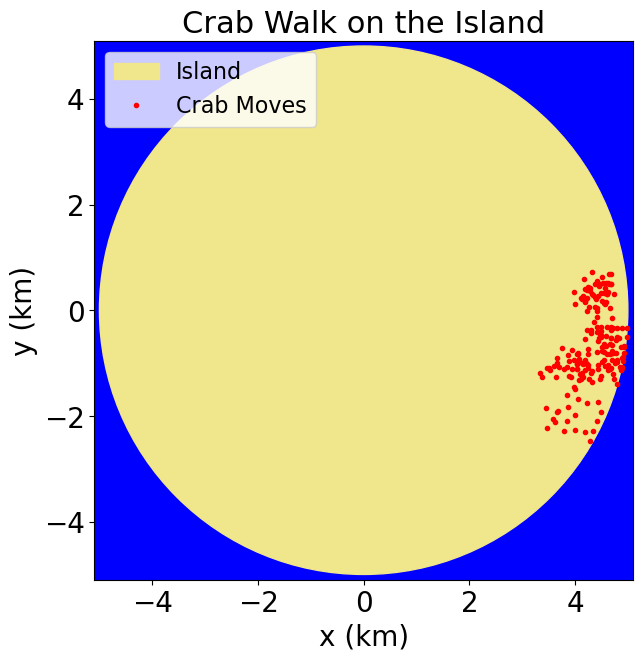

In [71]:
fig, ax = plt.subplots(figsize=(7, 7))
circle = plt.Circle((0, 0), 5, color='khaki', label='Island', alpha = 1)
radii = np.sqrt(pos[:, 0]**2 + pos[:, 1]**2)
ax.set_facecolor('blue')
ax.add_patch(circle)
ax.set_xlim(-5.1, 5.1)
ax.set_ylim(-5.1, 5.1)
ax.set_aspect('equal')
ax.plot(pos[1:, 0], pos[1:, 1], '.', color = 'red', label='Crab Moves')
ax.set_xlabel('x (km)', fontsize=20)
ax.set_ylabel('y (km)', fontsize=20)
ax.set_title('Crab Walk on the Island', fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=20)
ax.legend(loc='upper left', fontsize=16);
print(np.max(radii))
## It does look like some of the points are crossing the circle boundary, but they are just on the boundary as seen by the max of the radii. It is due to the markersize

## Problem 3b

In [72]:
def crab_travel(Nexperiments):
    distances = np.zeros(Nexperiments)
    for i in range(Nexperiments):
        x = 3.6
        y = -2
        R = 5
        step = 0.2
        total_dist = 0
        while True:
            theta = r.uniform(0, 2*np.pi)
            vx = np.cos(theta)
            vy = np.sin(theta)
            dist = np.sqrt((vx*step)**2 + (vy*step)**2)
            x += vx*step
            y += vy*step
            if np.sqrt(x**2 + y**2) > R:
                scale = R / np.sqrt(x**2 + y**2)
                xdum = x - vx*step
                ydum = y - vy*step
                x *= scale
                y *= scale
                total_dist += np.sqrt((x-xdum)**2+(y-ydum)**2)
                break
            total_dist += dist
        distances[i] = total_dist
    return distances

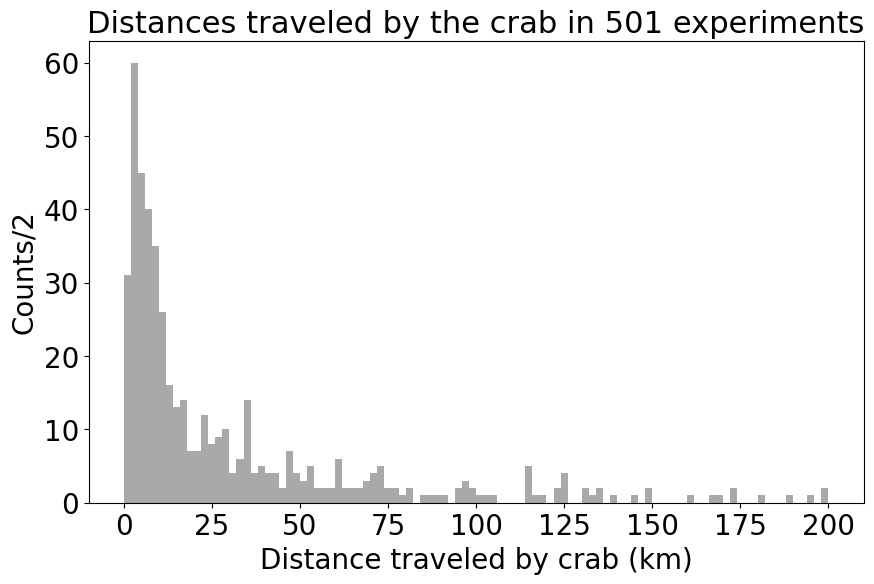

In [73]:
r.seed(42)
distTravel = crab_travel(501)
xmin = 0
xmax = 200
Nbins = 100
binwidth = (xmax - xmin) / Nbins
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(distTravel, bins=Nbins, range=(xmin, xmax), label='Data', color='darkgray')
ax.set_xlabel('Distance traveled by crab (km)', fontsize=20)
ax.set_ylabel(f'Counts/{binwidth:.0f}', fontsize=20)
ax.set_title('Distances traveled by the crab in 501 experiments', fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=20)

## Problem 3c

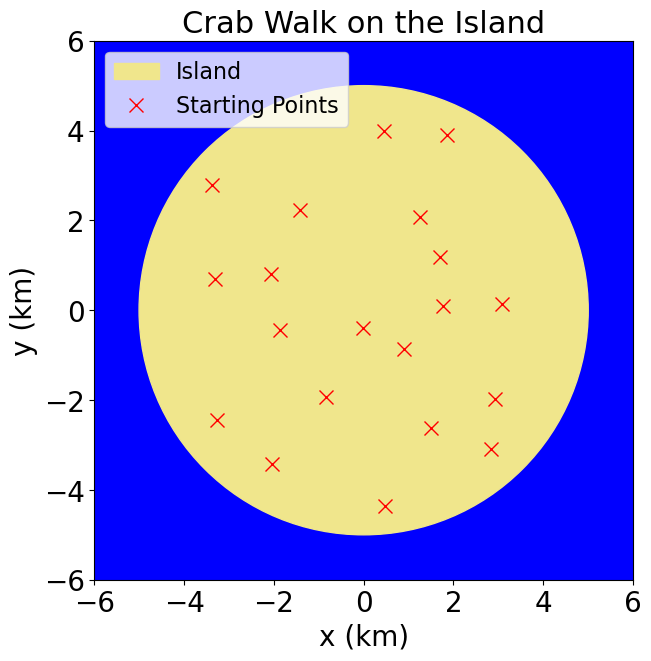

In [74]:
crabPosOriginal = np.loadtxt('CrabStartPositions.txt')
fig, ax = plt.subplots(figsize=(7, 7))
circle = plt.Circle((0, 0), 5, color='khaki', label='Island', alpha = 1)
ax.set_facecolor('blue')
ax.add_patch(circle)
ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)
ax.set_aspect('equal')
ax.plot(crabPosOriginal[:, 0], crabPosOriginal[:, 1], 'x', color = 'red', markersize=10, label='Starting Points')
ax.set_xlabel('x (km)', fontsize=20)
ax.set_ylabel('y (km)', fontsize=20)
ax.set_title('Crab Walk on the Island', fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=20)
ax.legend(loc='upper left', fontsize=16);

In [75]:
from numba import njit

@njit
def crabOdds(m1, m2):
    if m1 >= m2:
        mLarge = m1
        mSmall = m2
        large_first = True
    else:
        mLarge = m2
        mSmall = m1
        large_first = False

    odds = (mLarge*mLarge) / (mSmall*mSmall + mLarge*mLarge)

    if np.random.random() < odds:
        mLarge = mLarge + mSmall
        mSmall = 0.0

    if large_first:
        return mLarge, mSmall
    else:
        return mSmall, mLarge
    
@njit
def crabmove(x0, y0, step=0.2, R=5.0):
    theta = np.random.random() * 2.0 * np.pi
    vx = np.cos(theta)
    vy = np.sin(theta)

    xMove = x0 + vx * step
    yMove = y0 + vy * step

    dist = np.sqrt(xMove**2 + yMove**2)
    if dist > R:
        scale = R / dist
        xMove *= scale
        yMove *= scale
    return xMove, yMove

@njit
def crabs_3c(startPos=crabPosOriginal):
    positions = startPos.copy()
    masses = np.ones(len(startPos))
    for day in range(200):

        # Update positions:
        for i in range(len(positions)):
            x = positions[i][0]
            y = positions[i][1]
            x_new, y_new = crabmove(x, y)
            positions[i][0], positions[i][1] = x_new, y_new

        pairs = []

        for i in range(len(positions)): #Identify which crabs will battle, and store the pairs so that they can be sorted by distance
            for j in range(i+1, len(positions)):

                if masses[i] == 0 or masses[j] == 0: #Make sure that eliminated crabs do not battle (although crab_fight can handle this anyways)
                    continue

                dx = positions[i][0] - positions[j][0]
                dy = positions[i][1] - positions[j][1]
                dist2 = dx**2 + dy**2

                if dist2 < 0.175**2:
                    pairs.append((dist2, i, j))
        pairs.sort(key=lambda x: x[0]) #Sort the pairs by squared distances

        for dist2, i, j in pairs:
            if masses[i] == 0 or masses[j] == 0: #Make sure that eliminated crabs do not battle (although crab_fight can handle this anyways)
                continue
            new_masses = crabOdds(masses[i], masses[j])
            masses[i], masses[j] = new_masses

        num_crabs = np.count_nonzero(masses)
        #mass_tot = np.sum(masses) #Check that the total mass is correct
    final_mass = max(masses)
    return final_mass, num_crabs

Ntrials = 10000

masses = np.ones(Ntrials)
Ncrabs = np.ones(Ntrials)

for i in range(Ntrials):
    final_mass, num_crabs = crabs_3c()
    masses[i] = final_mass
    Ncrabs[i] = num_crabs

### Plots

In [76]:
# np.savetxt('CrabBattleResults.txt', np.column_stack((Ncrabs, masses)), fmt='%d %.1f')

In [77]:
crabs, masses = np.loadtxt('CrabBattleResults.txt', unpack=True)
crabs = crabs.astype(int)
masses = masses.astype(float)
print(crabs)

[13 12 13 ... 13 13 11]


The most likely amount of crabs remaining alive after 200 days is 13
The most likely mass of the largest crab is 3


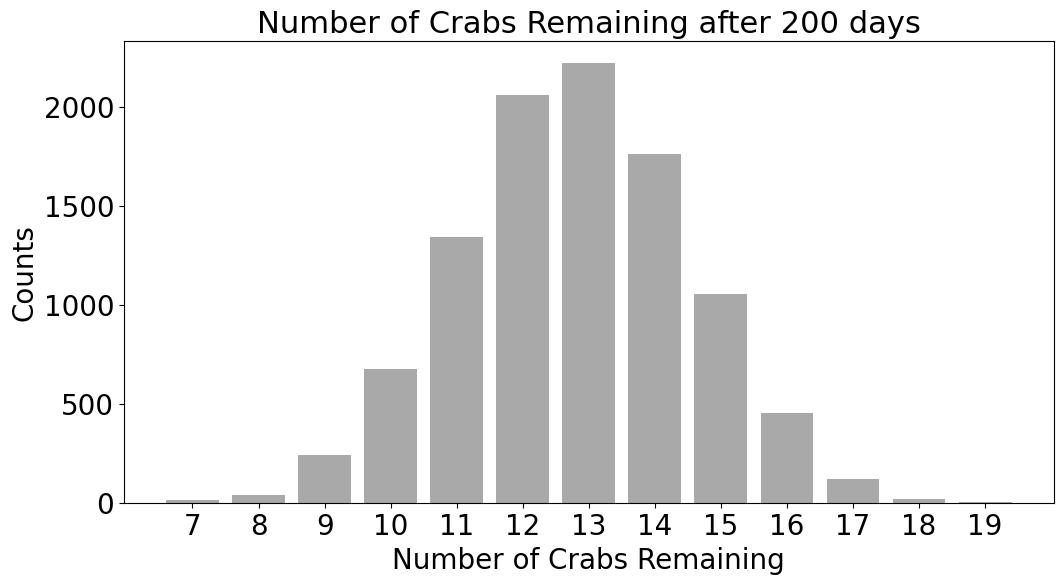

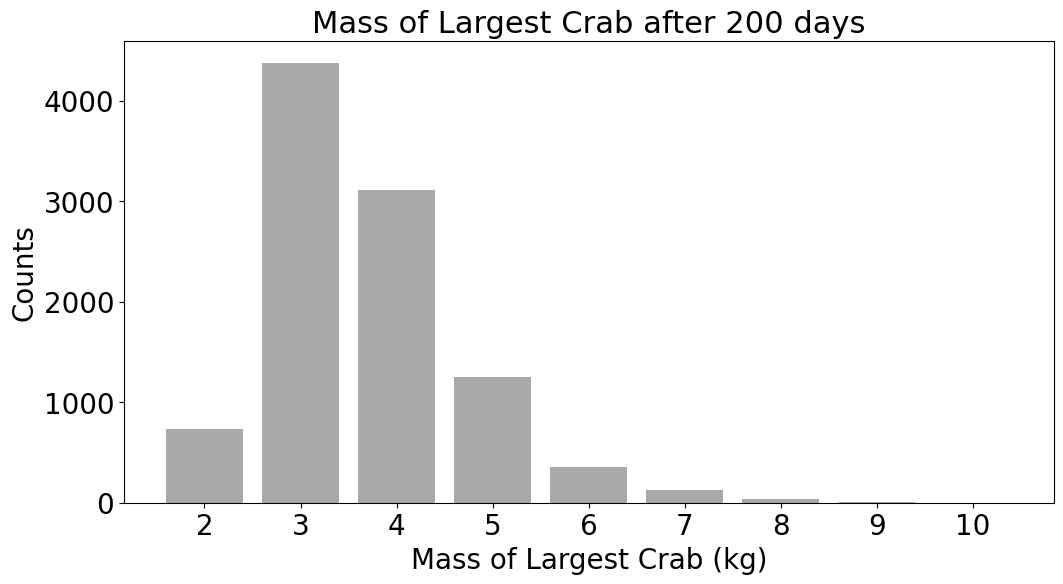

In [78]:
unique_crabs, crab_counts = np.unique(crabs, return_counts=True)
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(unique_crabs, crab_counts, color='darkgray', width=0.8)

ax.set_xlabel('Number of Crabs Remaining', fontsize=20)
ax.set_ylabel('Counts', fontsize=20)
ax.set_title('Number of Crabs Remaining after 200 days', fontsize=22)
ax.set_xticks(unique_crabs)
ax.tick_params(axis='both', which='major', labelsize=20)


unique_masses, mass_counts = np.unique(masses, return_counts=True)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(unique_masses, mass_counts, color='darkgray', width=0.8)

ax.set_xlabel('Mass of Largest Crab (kg)', fontsize=20)
ax.set_ylabel('Counts', fontsize=20)
ax.set_title('Mass of Largest Crab after 200 days', fontsize=22)
ax.set_xticks(unique_masses)
ax.tick_params(axis='both', which='major', labelsize=20)

print('The most likely amount of crabs remaining alive after 200 days is',
      stats.mode(crabs, keepdims=True)[0][0])

print('The most likely mass of the largest crab is',
      int(stats.mode(masses, keepdims=True)[0][0]))

In [79]:
print(crab_counts)
print(mass_counts)

[  13   40  239  673 1343 2059 2221 1762 1053  451  122   21    3]
[ 738 4378 3108 1255  358  122   34    5    2]


## Problem 3d

In [80]:
@njit
def crabs_3d(startPos=crabPosOriginal, fight_distance=0.175):
    positions = startPos.copy()
    masses = np.ones(len(startPos))
    days = 0
    while True:

        # Update positions:
        for i in range(len(positions)):
            x = positions[i][0]
            y = positions[i][1]
            x_new, y_new = crabmove(x, y)
            positions[i][0], positions[i][1] = x_new, y_new
        days +=1

        pairs = []

        for i in range(len(positions)):
            for j in range(i+1, len(positions)):

                if masses[i] == 0 or masses[j] == 0: #Make sure that eliminated crabs do not battle (although crab_fight can handle this anyways)
                    continue

                dx = positions[i][0] - positions[j][0]
                dy = positions[i][1] - positions[j][1]
                dist2 = dx**2 + dy**2

                if dist2 < fight_distance**2:
                    pairs.append((dist2, i, j))
        pairs.sort(key=lambda x: x[0])

        for dist2, i, j in pairs:
            if masses[i] == 0 or masses[j] == 0: #Make sure that eliminated crabs do not battle (although crab_fight can handle this anyways)
                continue
            new_masses = crabOdds(masses[i], masses[j])
            masses[i], masses[j] = new_masses

        num_crabs = np.count_nonzero(masses)
        if num_crabs <= 10:
            break
    return days
Ntrials = 10000
daysList = np.zeros(Ntrials)
for i in range(Ntrials):
    days = crabs_3d(startPos=crabPosOriginal, fight_distance=0.175)
    daysList[i] = days

In [81]:
# np.savetxt('Days.txt', daysList, fmt='%d')
daysList = np.loadtxt('Days.txt', unpack=True)

### Plot

In [82]:
# 68.27% central interval percentiles
lower_p = 15.865
upper_p = 84.135

# Alpha interval
CILow, CIHigh = np.percentile(daysList, [lower_p, upper_p])
CI = np.array([CILow, CIHigh])
print(f"68.27% confidence interval for days to reach 10 crabs: [{CI[0]}, {CI[1]}]")
print(CI-np.mean(daysList))

68.27% confidence interval for days to reach 10 crabs: [222.0, 425.0]
[-100.924  102.076]


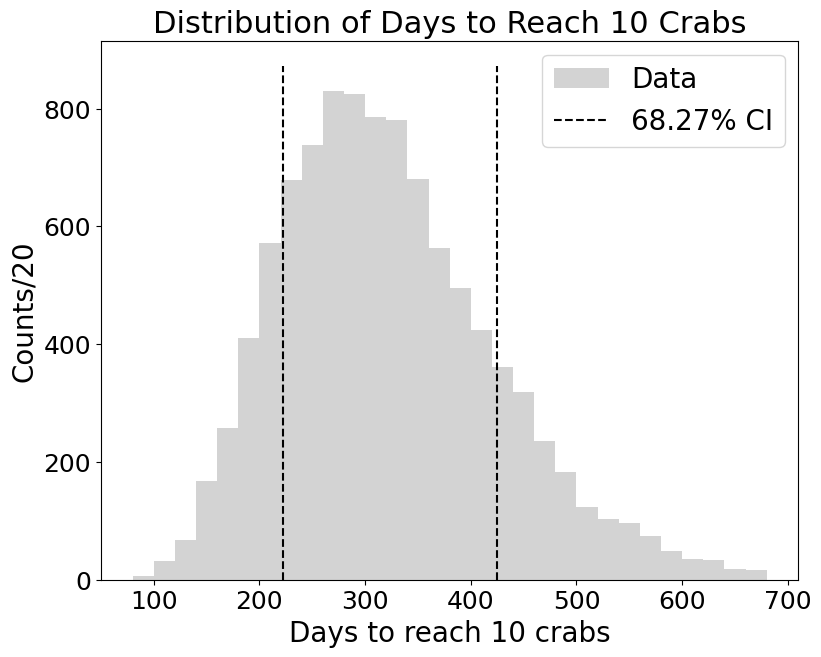

In [83]:
fig, ax = plt.subplots(figsize=(9, 7))
xmin, xmax = 80, 680
Nbins = 30
binwidth = (xmax - xmin) / Nbins
ax.hist(daysList, bins=Nbins, range=(xmin, xmax), color='lightgray', label='Data')
# ax.hist(days[(days > CI[0]) & (days < CI[1])], bins=Nbins, range=(xmin, xmax), color='red', alpha=0.3, label='Data within 68.27% CI')
ymin, ymax = ax.get_ylim()
ax.vlines(CI, ymin, ymax, linestyles='dashed', color='black', label='68.27% CI')
ax.set_xlabel('Days to reach 10 crabs', fontsize=20)
ax.set_ylabel(f'Counts/{binwidth:.0f}', fontsize=20)
ax.set_title('Distribution of Days to Reach 10 Crabs', fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.legend(fontsize=20);